In [1]:
using Plots
using LinearAlgebra
using Colors

gr()

# --- Целевые функции (2D) ---
function rosenbrock_2d(x)
    return (1.0 - x[1])^2 + 100.0 * (x[2] - x[1]^2)^2
end

function rastrigin_2d(x)
    n = length(x)
    return 10 * n + sum(x[i]^2 - 10 * cos(2 * pi * x[i]) for i in 1:n)
end

function schwefel_2d(x)
    n = length(x)
    return 418.9829 * n - sum(x[i] * sin(sqrt(abs(x[i]))) for i in 1:n)
end

# --- Начальный симплекс (регулярный, как в 3D-ноутбуке) ---
function create_initial_simplex(x0, n, alpha=1.0)
    simplex = [copy(x0)]
    q = (sqrt(n + 1) - 1) / (n * sqrt(2))
    p = q + 1 / sqrt(2)
    for i in 1:n
        x_new = copy(x0)
        for j in 1:n
            if j == i
                x_new[j] += alpha * p
            else
                x_new[j] += alpha * q
            end
        end
        push!(simplex, x_new)
    end
    return simplex
end

function simplex_method(f, x0, eps=1e-3, alpha=1.0, max_iterations=5000)
    n = length(x0)
    simplex = create_initial_simplex(x0, n, alpha)
    trajectory = [copy(x0)]
    all_simplexes = [copy(simplex)]
    iteration = 0
    while iteration < max_iterations
        iteration += 1
        vals = [f(p) for p in simplex]
        worst_idx = argmax(vals)
        best_idx = argmin(vals)
        centroid_all = sum(simplex) / length(simplex)
        max_distance = maximum([norm(p - centroid_all) for p in simplex])
        if max_distance < eps
            break
        end
        centroid = (sum(simplex) - simplex[worst_idx]) / (length(simplex) - 1)
        x_reflected = 2.0 .* centroid .- simplex[worst_idx]
        f_reflected = f(x_reflected)
        if f_reflected < vals[worst_idx]
            simplex[worst_idx] = x_reflected
            push!(trajectory, copy(x_reflected))
        else
            x_best = copy(simplex[best_idx])
            for i in 1:length(simplex)
                if i != best_idx
                    simplex[i] = x_best .+ 0.5 .* (simplex[i] .- x_best)
                end
            end
            push!(trajectory, copy(x_best))
        end
        push!(all_simplexes, copy(simplex))
    end
    best_index = argmin([f(p) for p in simplex])
    result = simplex[best_index]
    return result, trajectory, all_simplexes, iteration
end

function create_initial_simplex_nm(x0, n, alpha=0.05)
    simplex = [copy(x0)]
    for i in 1:n
        x_new = copy(x0)
        x_new[i] += alpha
        push!(simplex, x_new)
    end
    return simplex
end

function nelder_mead_method(f, x0, eps=1e-3, alpha=1.0, max_iterations=5000)
    n = length(x0)
    simplex = create_initial_simplex_nm(x0, n, 0.05)
    α_nm = 1.0
    β_nm = 2.0
    ρ_nm = 0.5
    δ_nm = 0.5
    trajectory = [copy(x0)]
    all_simplexes = [copy(simplex)]
    iteration = 0
    while iteration < max_iterations
        iteration += 1
        simplex = sort(simplex, by=f)
        best = simplex[1]
        worst = simplex[end]
        second_worst = simplex[end-1]
        centroid = sum(simplex[1:end-1]) / (length(simplex) - 1)
        max_distance = maximum([norm(p - centroid) for p in simplex])
        if max_distance < eps
            break
        end
        centroid = sum(simplex[1:end-1]) / (length(simplex) - 1)
        x_reflected = centroid .+ α_nm .* (centroid .- worst)
        f_reflected = f(x_reflected)
        f_best = f(best)
        f_second_worst = f(second_worst)
        f_worst = f(worst)
        if f_reflected < f_best
            x_expanded = centroid .+ β_nm .* (x_reflected .- centroid)
            f_expanded = f(x_expanded)
            if f_expanded < f_reflected
                simplex[end] = x_expanded
                push!(trajectory, copy(x_expanded))
            else
                simplex[end] = x_reflected
                push!(trajectory, copy(x_reflected))
            end
        elseif f_reflected < f_second_worst
            simplex[end] = x_reflected
            push!(trajectory, copy(x_reflected))
        else
            if f_reflected < f_worst
                x_contracted = centroid .+ ρ_nm .* (x_reflected .- centroid)
            else
                x_contracted = centroid .+ ρ_nm .* (worst .- centroid)
            end
            f_contracted = f(x_contracted)
            if f_contracted < min(f_reflected, f_worst)
                simplex[end] = x_contracted
                push!(trajectory, copy(x_contracted))
            else
                for i in 2:length(simplex)
                    simplex[i] = best .+ δ_nm .* (simplex[i] .- best)
                end
                push!(trajectory, copy(best))
            end
        end
        push!(all_simplexes, copy(simplex))
    end
    result = simplex[1]
    return result, trajectory, all_simplexes, iteration
end

function get_red_gradient_color(t)
    r = clamp(1.0 - 0.7 * t, 0.0, 1.0)
    g = clamp(0.7 - 0.7 * t, 0.0, 1.0)
    b = clamp(0.7 - 0.7 * t, 0.0, 1.0)
    return RGB(r, g, b)
end

function get_blue_gradient_color(t)
    r = clamp(0.7 - 0.7 * t, 0.0, 1.0)
    g = clamp(0.7 - 0.7 * t, 0.0, 1.0)
    b = clamp(1.0 - 0.7 * t, 0.0, 1.0)
    return RGB(r, g, b)
end

function plot_triangle!(plt, simplex, color, alpha_val, label_str)
    length(simplex) < 3 && return
    xs = Float64[simplex[1][1], simplex[2][1], simplex[3][1], simplex[1][1]]
    ys = Float64[simplex[1][2], simplex[2][2], simplex[3][2], simplex[1][2]]
    plot!(plt, xs, ys; seriestype=:shape, fillcolor=color, fillalpha=alpha_val,
          lw=0.8, linecolor=color, label=label_str)
end

function subsample_indices(n_total, max_show)
    n_total <= max_show && return collect(1:n_total)
    unique(round.(Int, range(1.0, float(n_total), length=max_show)))
end

function axis_limits_from_points(points, pad_frac=0.12)
    xs = [p[1] for p in points]
    ys = [p[2] for p in points]
    dx = maximum(xs) - minimum(xs)
    dy = maximum(ys) - minimum(ys)
    m = max(dx, dy, 0.5)
    pad = pad_frac * m
    (minimum(xs) - pad, maximum(xs) + pad), (minimum(ys) - pad, maximum(ys) + pad)
end

function plot_comparison_2d(f, x0, result_simple, result_nm,
                            traj_simple, traj_nm,
                            simplexes_simple, simplexes_nm,
                            title_str; ngrid=90, max_triangles=70)
    pts = vcat(traj_simple, traj_nm, [x0], [result_simple], [result_nm])
    xlim, ylim = axis_limits_from_points(pts)
    xs = range(xlim[1], xlim[2]; length=ngrid)
    ys = range(ylim[1], ylim[2]; length=ngrid)
    Z = [f([xi, yj]) for yj in ys, xi in xs]

    plt1 = plot(; legend=:topright, size=(560, 480), dpi=110, title="Простой симплекс",
                xlabel="x1", ylabel="x2", aspect_ratio=:equal)
    contour!(plt1, xs, ys, Z; color=:thermal, levels=15, colorbar=:right)
    n_s = length(simplexes_simple)
    for (k, idx) in enumerate(subsample_indices(n_s, max_triangles))
        simplex = simplexes_simple[idx]
        t = (idx - 1) / max(n_s - 1, 1)
        color = get_red_gradient_color(t)
        lbl = (k == 1 && idx == 1) ? "Симплексы (светл.→тёмн.)" : ""
        plot_triangle!(plt1, simplex, color, 0.35, lbl)
    end
    plot!(plt1, [p[1] for p in traj_simple], [p[2] for p in traj_simple];
          lw=1.2, color=:black, alpha=0.6, label="Траектория")
    scatter!(plt1, [x0[1]], [x0[2]]; color=:lime, ms=5, label="Старт")
    scatter!(plt1, [result_simple[1]], [result_simple[2]];
             color=:black, ms=7, shape=:star5, label="Финиш")

    plt2 = plot(; legend=:topright, size=(560, 480), dpi=110, title="Нельдер–Мид",
                xlabel="x1", ylabel="x2", aspect_ratio=:equal)
    contour!(plt2, xs, ys, Z; color=:thermal, levels=15, colorbar=:right)
    n_m = length(simplexes_nm)
    for (k, idx) in enumerate(subsample_indices(n_m, max_triangles))
        simplex = simplexes_nm[idx]
        t = (idx - 1) / max(n_m - 1, 1)
        color = get_blue_gradient_color(t)
        lbl = (k == 1 && idx == 1) ? "Симплексы (светл.→тёмн.)" : ""
        plot_triangle!(plt2, simplex, color, 0.35, lbl)
    end
    plot!(plt2, [p[1] for p in traj_nm], [p[2] for p in traj_nm];
          lw=1.2, color=:black, alpha=0.6, label="Траектория")
    scatter!(plt2, [x0[1]], [x0[2]]; color=:lime, ms=5, label="Старт")
    scatter!(plt2, [result_nm[1]], [result_nm[2]];
             color=:black, ms=7, shape=:star5, label="Финиш")

    combined = plot(plt1, plt2; layout=(1, 2), size=(1120, 480), plot_title=title_str)
    return combined
end

function compare_methods_2d(f, f_name, x0; kwargs...)
    println("\n" * "="^70)
    println("СРАВНЕНИЕ МЕТОДОВ: $f_name (2D)")
    println("Начальная точка: $x0")
    println("="^70)

    result_simple, traj_simple, simplexes_simple, iter_simple = simplex_method(f, x0)
    result_nm, traj_nm, simplexes_nm, iter_nm = nelder_mead_method(f, x0)

    f_simple = f(result_simple)
    f_nm = f(result_nm)

    println("\n--- Метод простого симплекса ---")
    println("Результат: $result_simple")
    println("Значение функции: $f_simple")
    println("Количество итераций: $iter_simple")
    println("Количество записей симплексов: $(length(simplexes_simple))")
    println("Количество точек траектории: $(length(traj_simple))")

    println("\n--- Метод Нельдера–Мида ---")
    println("Результат: $result_nm")
    println("Значение функции: $f_nm")
    println("Количество итераций: $iter_nm")
    println("Количество записей симплексов: $(length(simplexes_nm))")
    println("Количество точек траектории: $(length(traj_nm))")

    println("\nЛучшее значение функции:")
    if f_simple < f_nm
        println("Простой симплекс: $f_simple (лучше на $(f_nm - f_simple))")
    elseif f_nm < f_simple
        println("Нельдер–Мид: $f_nm (лучше на $(f_simple - f_nm))")
    else
        println("Оба метода дали одинаковый результат: $f_simple")
    end

    title_2d = "Сравнение методов — $f_name (2D)"
    plt = plot_comparison_2d(f, x0, result_simple, result_nm,
                             traj_simple, traj_nm,
                             simplexes_simple, simplexes_nm,
                             title_2d; kwargs...)
    display(plt)
    return result_simple, result_nm, traj_simple, traj_nm, plt
end



compare_methods_2d (generic function with 1 method)


СРАВНЕНИЕ МЕТОДОВ: Розенброк (2D)
Начальная точка: [1.5, 2.0]

--- Метод простого симплекса ---
Результат: [1.7142136591141721, 2.939964857382785]
Значение функции: 0.510307471996986
Количество итераций: 25
Количество записей симплексов: 25
Количество точек траектории: 25

--- Метод Нельдера–Мида ---
Результат: [1.0000446035411659, 1.0000655297895502]
Значение функции: 5.8060316707278433e-8
Количество итераций: 48
Количество записей симплексов: 48
Количество точек траектории: 48

Лучшее значение функции:
Нельдер–Мид: 5.8060316707278433e-8 (лучше на 0.5103074139366693)


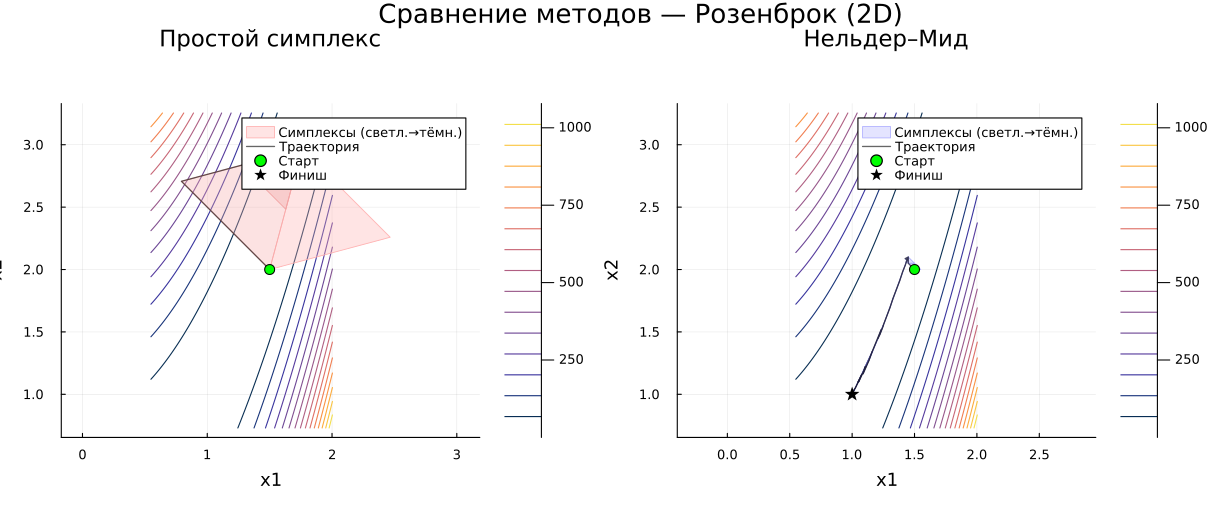


СРАВНЕНИЕ МЕТОДОВ: Растригин (2D)
Начальная точка: [0.5, 0.5]

--- Метод простого симплекса ---
Результат: [1.9902657321815627, 1.990265732181563]
Значение функции: 7.9597118669539775
Количество итераций: 22
Количество записей симплексов: 22
Количество точек траектории: 22

--- Метод Нельдера–Мида ---
Результат: [0.9947777039953518, 0.9951485308702122]
Значение функции: 1.9899317560508791
Количество итераций: 28
Количество записей симплексов: 28
Количество точек траектории: 28

Лучшее значение функции:
Нельдер–Мид: 1.9899317560508791 (лучше на 5.969780110903098)


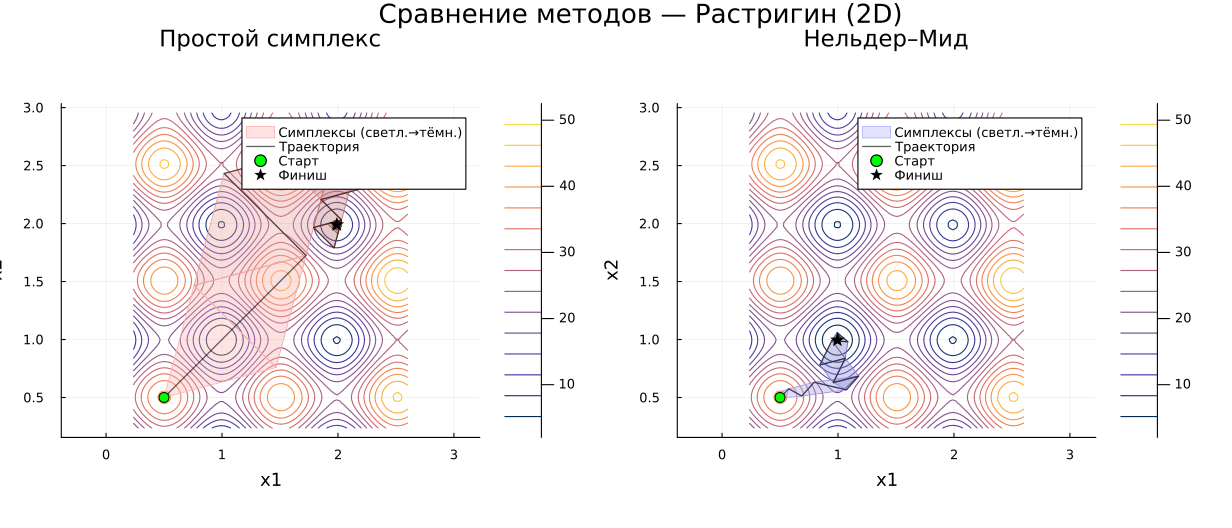


СРАВНЕНИЕ МЕТОДОВ: Швефель (2D)
Начальная точка: [0.5, 0.5]

--- Метод простого симплекса ---
Результат: [5.239653424101329, 5.238962890135328]
Значение функции: 830.0751968023602
Количество итераций: 29
Количество записей симплексов: 29
Количество точек траектории: 29

--- Метод Нельдера–Мида ---
Результат: [5.239102534612844, 5.239406004461574]
Значение функции: 830.0751967599498
Количество итераций: 46
Количество записей симплексов: 46
Количество точек траектории: 46

Лучшее значение функции:
Нельдер–Мид: 830.0751967599498 (лучше на 4.2410420064697973e-8)


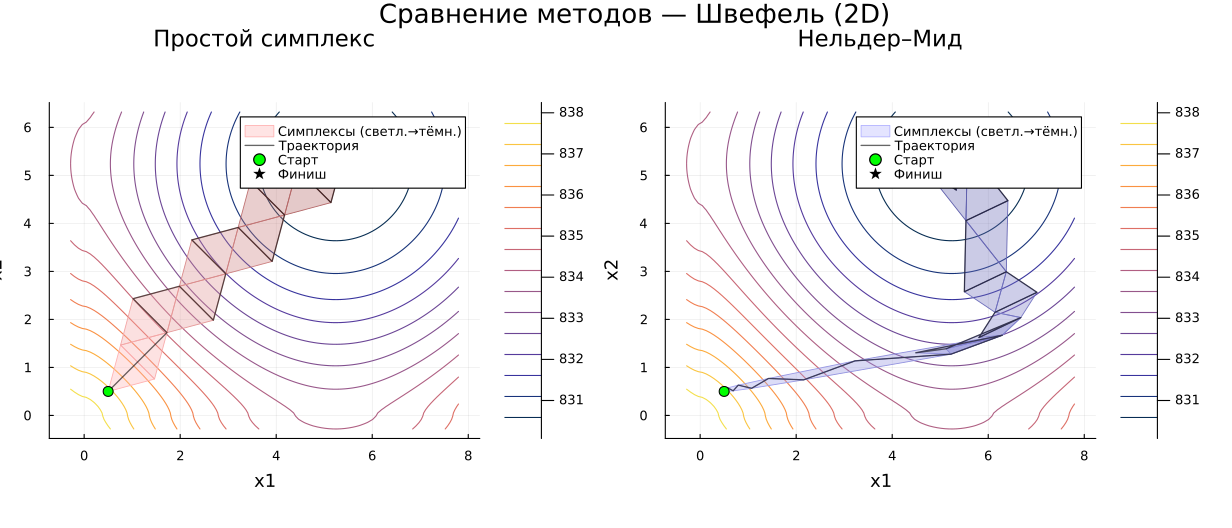

([5.239653424101329, 5.238962890135328], [5.239102534612844, 5.239406004461574], [[0.5, 0.5], [1.724744871391589, 1.724744871391589], [1.0176380902050415, 2.4318516525781364], [1.9835639164941097, 2.6906706976806567], [2.690670697680657, 1.9835639164941092], [2.9494897427831774, 2.9494897427831774], [2.242382961596629, 3.656596523969725], [3.2083087878856964, 3.915415569072245], [3.9154155690722448, 3.208308787885697], [4.174234614174765, 4.174234614174765]  …  [5.245886376642404, 5.245886376642404], [5.245886376642404, 5.245886376642404], [5.245886376642404, 5.245886376642404], [5.241842329062678, 5.230793785606638], [5.2383400811245195, 5.243864352852542], [5.236318057334658, 5.236318057334658], [5.241102216988529, 5.241102216988533], [5.237329069229588, 5.2400912050936], [5.240596711041064, 5.239215643109061], [5.238710137161593, 5.238710137161595]], [[0.5, 0.5], [0.5750000000000001, 0.5750000000000001], [0.6875, 0.5125000000000002], [0.7937500000000002, 0.6312500000000005], [1.0718

In [2]:
x0_rosenbrock_2d = [1.5, 2.0]
compare_methods_2d(rosenbrock_2d, "Розенброк", x0_rosenbrock_2d)

x0_rastrigin_2d = [0.5, 0.5]
compare_methods_2d(rastrigin_2d, "Растригин", x0_rastrigin_2d)

x0_schwefel_2d = [0.5, 0.5]
compare_methods_2d(schwefel_2d, "Швефель", x0_schwefel_2d; ngrid=100, max_triangles=80)

